# Laboratorio 9 -  Teoría de Probabilidades

Julián Divas

Luis Ángel Girón

### Preguntas a responder

- ¿Cuál es la probabilidad de llenar un equipo completo del álbum comprando una caja?

- ¿Cuál es la probabilidad de encontrar todas las estampas de campeones históricos comprando una caja?

- ¿Cuál es la probabilidad de llenar el mismo equipo dos veces comprando una caja?

- ¿Cuál es el valor esperado de estampas repetidas en una caja?

- ¿Cuál es el costo esperado para completar una selección comprando sobres?

PREGUNTA 1
Probabilidad de llenar un equipo completo
comprando una caja:
0.0000

PREGUNTA 2
Probabilidad de obtener todas las estampas
de campeones históricos comprando una caja:
0.0007

PREGUNTA 3
Probabilidad de llenar el mismo equipo
dos veces comprando una caja:
0.000000

PREGUNTA 4
Valor esperado de estampas repetidas
en una caja:
214.07


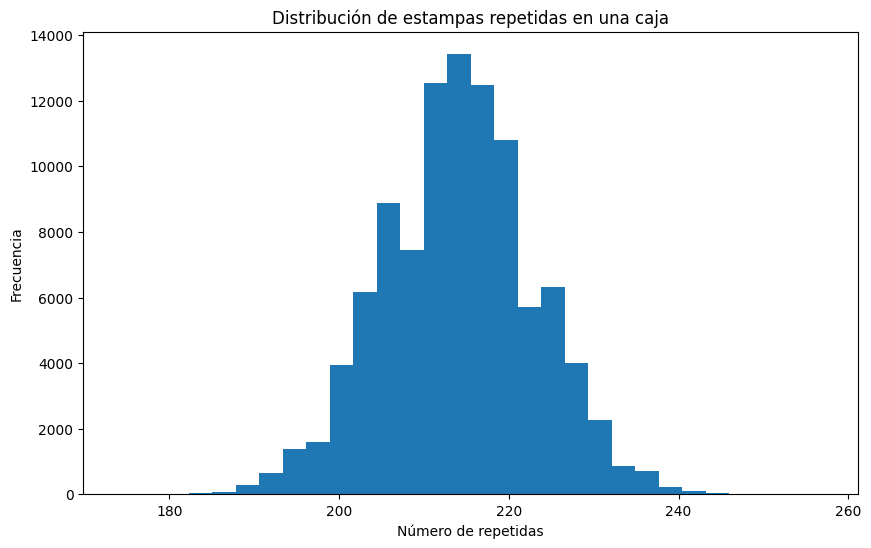


PREGUNTA 5
Costo esperado para completar una selección
comprando sobres:
Q5935.11

Sobres promedio necesarios:
624.75


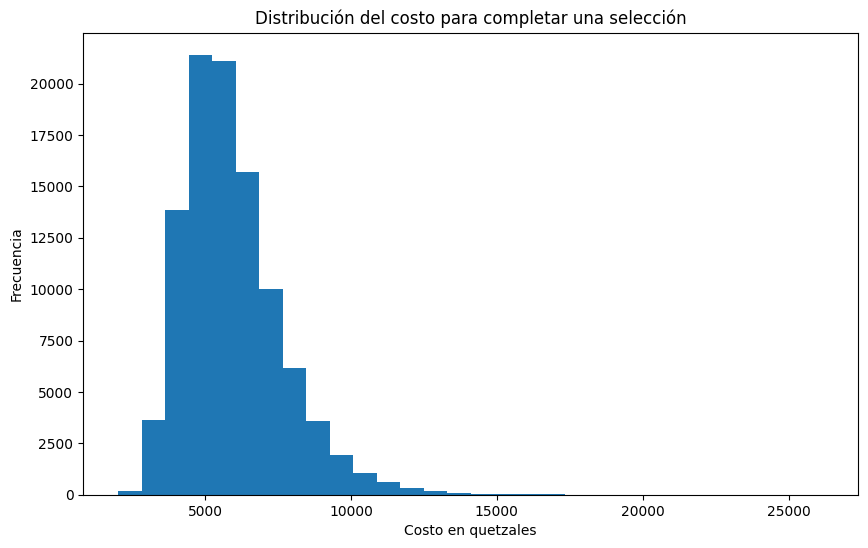


INTERVALOS DE CONFIANZA 95%

Estampas repetidas:
IC95% = (214.02, 214.13)

Costo esperado:
IC95% = (Q5924.60, Q5945.61)

REFLEXIÓN FINAL

La simulación muestra que completar partes específicas
del álbum puede requerir muchos sobres incluso cuando
se compra una caja completa.

Las estampas repetidas aparecen con mucha frecuencia
debido al gran tamaño del álbum (980 estampas).

También se observa que completar una selección específica
puede tener un costo considerable, especialmente porque
las últimas estampas faltantes son difíciles de obtener.

El método Monte Carlo permite aproximar probabilidades
y costos de forma efectiva cuando el análisis teórico
es complicado.



In [5]:
# ============================================================
# SIMULACIÓN DEL ÁLBUM DEL MUNDIAL 2026
# ============================================================
# Autor: Equipo
# Tema: Simulación Monte Carlo
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

# Datos oficiales
N = 980                 # Total de estampas
S = 7                   # Estampas por sobre
PRECIO_SOBRE = 9.50     # Quetzales
SOBRES_CAJA = 104
PRECIO_CAJA = 975.00

# Cantidad de simulaciones
SIMULACIONES = 100000

random.seed(2026)
np.random.seed(2026)

# ============================================================
# SUPOSICIONES DEL MODELO
# ============================================================

# Debido a que Panini aún no ha publicado la distribución exacta
# de estampas del álbum 2026, se harán las siguientes suposiciones:
#
# 1. Todas las estampas tienen la misma probabilidad de aparecer.
# 2. Las estampas se generan independientemente.
# 3. Un equipo tiene 20 estampas.
# 4. Hay 11 estampas de campeones históricos.
#
# Estas suposiciones permiten modelar el problema
# mediante simulación Monte Carlo.

# ============================================================
# DEFINICIÓN DE GRUPOS ESPECIALES
# ============================================================

# Equipo ejemplo:
# Seleccionamos 20 IDs arbitrarios para representar un equipo.
equipo = set(range(0, 48))

# Campeones históricos:
campeones = set(range(20, 31))

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def abrir_sobre():
    """
    Genera un sobre con S estampas aleatorias.
    """
    return np.random.randint(0, N, S)

def abrir_caja():
    """
    Genera una caja completa de sobres.
    """
    estampas = []

    for _ in range(SOBRES_CAJA):
        estampas.extend(abrir_sobre())

    return estampas

# ============================================================
# PREGUNTA 1
# ¿Cuál es la probabilidad de llenar un equipo completo
# comprando una caja?
# ============================================================

exitos = 0

for _ in range(SIMULACIONES):

    estampas = abrir_caja()
    unicas = set(estampas)

    if equipo.issubset(unicas):
        exitos += 1

prob_equipo = exitos / SIMULACIONES

print("================================================")
print("PREGUNTA 1")
print("Probabilidad de llenar un equipo completo")
print("comprando una caja:")
print(f"{prob_equipo:.4f}")
print("================================================")

# ============================================================
# PREGUNTA 2
# ¿Cuál es la probabilidad de encontrar todas las estampas
# de campeones históricos comprando una caja?
# ============================================================

exitos = 0

for _ in range(SIMULACIONES):

    estampas = abrir_caja()
    unicas = set(estampas)

    if campeones.issubset(unicas):
        exitos += 1

prob_campeones = exitos / SIMULACIONES

print("\n================================================")
print("PREGUNTA 2")
print("Probabilidad de obtener todas las estampas")
print("de campeones históricos comprando una caja:")
print(f"{prob_campeones:.4f}")
print("================================================")

# ============================================================
# PREGUNTA 3
# ¿Cuál es la probabilidad de llenar el mismo equipo
# dos veces comprando una caja?
# ============================================================

# Para llenar el mismo equipo dos veces:
# cada estampa del equipo debe aparecer al menos 2 veces.

exitos = 0

for _ in range(SIMULACIONES):

    estampas = abrir_caja()

    valido = True

    for e in equipo:
        if estampas.count(e) < 2:
            valido = False
            break

    if valido:
        exitos += 1

prob_doble_equipo = exitos / SIMULACIONES

print("\n================================================")
print("PREGUNTA 3")
print("Probabilidad de llenar el mismo equipo")
print("dos veces comprando una caja:")
print(f"{prob_doble_equipo:.6f}")
print("================================================")

# ============================================================
# PREGUNTA 4
# ¿Cuál es el valor esperado de estampas repetidas
# en una caja?
# ============================================================

repetidas_lista = []

for _ in range(SIMULACIONES):

    estampas = abrir_caja()

    total = len(estampas)
    distintas = len(set(estampas))

    repetidas = total - distintas

    repetidas_lista.append(repetidas)

esperado_repetidas = np.mean(repetidas_lista)

print("\n================================================")
print("PREGUNTA 4")
print("Valor esperado de estampas repetidas")
print("en una caja:")
print(f"{esperado_repetidas:.2f}")
print("================================================")

# ============================================================
# GRÁFICA DE REPETIDAS
# ============================================================

plt.figure(figsize=(10,6))
plt.hist(repetidas_lista, bins=30)
plt.xlabel("Número de repetidas")
plt.ylabel("Frecuencia")
plt.title("Distribución de estampas repetidas en una caja")
plt.show()

# ============================================================
# PREGUNTA 5
# ¿Cuál es el costo esperado para completar
# una selección comprando sobres?
# ============================================================

# Se desea completar un equipo de 20 estampas.

costos = []
sobres_necesarios = []

for _ in range(SIMULACIONES):

    coleccion = set()
    sobres = 0

    while not equipo.issubset(coleccion):

        sobre = abrir_sobre()

        coleccion.update(sobre)

        sobres += 1

    costo = sobres * PRECIO_SOBRE

    costos.append(costo)
    sobres_necesarios.append(sobres)

costo_esperado = np.mean(costos)
sobres_promedio = np.mean(sobres_necesarios)

print("\n================================================")
print("PREGUNTA 5")
print("Costo esperado para completar una selección")
print("comprando sobres:")
print(f"Q{costo_esperado:.2f}")
print()
print("Sobres promedio necesarios:")
print(f"{sobres_promedio:.2f}")
print("================================================")

# ============================================================
# GRÁFICA DE COSTOS
# ============================================================

plt.figure(figsize=(10,6))
plt.hist(costos, bins=30)
plt.xlabel("Costo en quetzales")
plt.ylabel("Frecuencia")
plt.title("Distribución del costo para completar una selección")
plt.show()

# ============================================================
# INTERVALOS DE CONFIANZA
# ============================================================

def intervalo_confianza(datos):

    media = np.mean(datos)
    std = np.std(datos, ddof=1)

    error = 1.96 * std / np.sqrt(len(datos))

    return media - error, media + error

ic_repetidas = intervalo_confianza(repetidas_lista)
ic_costos = intervalo_confianza(costos)

print("\n================================================")
print("INTERVALOS DE CONFIANZA 95%")
print("================================================")

print("\nEstampas repetidas:")
print(f"IC95% = ({ic_repetidas[0]:.2f}, {ic_repetidas[1]:.2f})")

print("\nCosto esperado:")
print(f"IC95% = (Q{ic_costos[0]:.2f}, Q{ic_costos[1]:.2f})")

# ============================================================
# REFLEXIÓN FINAL
# ============================================================

print("\n================================================")
print("REFLEXIÓN FINAL")
print("================================================")

print("""
La simulación muestra que completar partes específicas
del álbum puede requerir muchos sobres incluso cuando
se compra una caja completa.

Las estampas repetidas aparecen con mucha frecuencia
debido al gran tamaño del álbum (980 estampas).

También se observa que completar una selección específica
puede tener un costo considerable, especialmente porque
las últimas estampas faltantes son difíciles de obtener.

El método Monte Carlo permite aproximar probabilidades
y costos de forma efectiva cuando el análisis teórico
es complicado.
""")